# Introdução

O Instacart é uma plataforma de entrega de supermercado onde os clientes podem fazer um pedido no supermercado e depois receber sua compra, semelhante ao funcionamento do Uber Eats e do iFood. O conjunto de dados que fornecemos foi modificado a partir do original. Reduzimos o tamanho dele para que seus cálculos sejam executados mais rapidamente e incluímos valores ausentes e duplicados. Também tivemos o cuidado de preservar as distribuições dos dados originais quando fizemos as alterações.

Você precisa completar três etapas. Para cada uma delas, escreva uma breve introdução descrevendo como você pretende concluir a etapa e justifique suas decisões em parágrafos explicativos a medida que você avança na solução. Escreva também uma conclusão para resumir suas conclusões e escolhas.

### Dicionário de dados

Há cinco tabelas no conjunto de dados, e você vai precisar usar todas elas para pré-processar seus dados e fazer AED. Abaixo está um dicionário que lista as colunas de cada tabela e descreve os dados contidos nelas.

- instacart_orders.csv: cada linha corresponde a um pedido no aplicativo da Instacart

    - 'order_id': é o número que identifica cada pedido de forma exclusiva
    - 'user_id': é o número de identificação exclusivo da conta de cada cliente
    - 'order_number': é o número de vezes que o cliente fez um pedido
    - 'order_dow': é o dia da semana em que o pedido foi feito (0 é domingo)
    - 'order_hour_of_day': é a hora do dia em que o pedido foi feito
    - 'days_since_prior_order': é o número de dias desde que o cliente fez seu pedido anterior

- products.csv: cada linha corresponde a um produto exclusivo que os clientes podem comprar

    - 'product_id': é o número de identificação unívoco de cada produto
    - 'product_name': é o nome do produto
    - 'aisle_id': é o número de identificação exclusivo de cada categoria de corredor do supermercado
    - 'department_id': é o número de identificação exclusivo de cada categoria de departamento do supermercado

- order_products.csv: cada linha corresponde a um item incluído em um pedido

    - 'order_id': é o número que identifica cada pedido de forma exclusiva
    - 'product_id': é o número de identificação exclusivo de cada produto
    - 'add_to_cart_order': é a ordem sequencial em que cada item foi colocado no carrinho
    - 'reordered': 0 se o cliente nunca comprou o produto antes, 1 se já o comprou

- aisles.csv

    - 'aisle_id': é o número de identificação exclusivo de cada categoria de corredor do supermercado
    - 'aisle': é o nome do corredor

- departments.csv

    - 'department_id': é o número de identificação exclusivo de cada categoria de departamento do supermercado
    - 'department': é o nome do departamento


# Etapa 1 - Visão geral dos dados

Leia os arquivos de dados (/datasets/instacart_orders.csv, /datasets/products.csv, /datasets/aisles.csv, /datasets/departments.csv e /datasets/order_products.csv) com pd.read_csv() usando os parâmetros apropriados para fazer isso corretamente. Verifique as informações para cada DataFrame criado.

### Plano de solução

Escreva aqui seu plano para a Etapa 1. Visão geral dos dados

Nesta etapa, os arquivos de dados serão carregados em variáveis que receberão o mesmo nome dos respectivos arquivos, a fim de facilitar a leitura e a compreensão. Em seguida, utilizarei o método .info() para verificar as informações contidas em cada arquivo. Após o uso do método info(), verificou-se que a pandas não identificou o separador das colunas, e para correção o parametro sep=';', foi utilizado.



In [11]:
# Importe as bibliotecas

import pandas as pd
from matplotlib import pyplot as plt

In [4]:
# leia os conjuntos de dados em DataFrames

instacart_orders = pd.read_csv('instacart_orders.csv', sep=';')
products = pd.read_csv('products.csv', sep=';')
aisles = pd.read_csv('aisles.csv', sep=';')
departments = pd.read_csv('departments.csv', sep=';')
order_products = pd.read_csv('order_products.csv', sep=';')

In [5]:
# imprima as informações sobre o DataFrame

instacart_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [6]:
# imprima as informações sobre o DataFrame

products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [7]:
# imprima as informações sobre o DataFrame

aisles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [9]:
# imprima as informações sobre o DataFrame

departments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 468.0+ bytes


In [10]:
# imprima as informações sobre o DataFrame

order_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype  
---  ------             -----  
 0   order_id           int64  
 1   product_id         int64  
 2   add_to_cart_order  float64
 3   reordered          int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


### Conclusões

Conclusões intermediárias da Etapa 1. Visão geral dos dados

No DataFrame orders, podemos notar a ausência de dados apenas na coluna 'days_since_prior_order'.

Analisando o seguinte DataFrame (product) nota-se que apenas a coluna 'product_name' possui dados ausentes.

Em análise prévia o seguinte DataFrame (aisles) não possui erros de dados nem estrutural.

Em análise prévia o seguinte DataFrame (departments) não possui erros de dados nem estrutural.

Em análise prévia o seguinte DataFrame (orders_products) não possui erros de dados nem estrutural. Mas o tipo de dados float precisa ser verificado para que a chance de valores ausentes seja descartadas. O uso do método isna().sum(), seria útil para ocasião.



# Etapa 2 - Preparação dos dados

Faça o pré-processamento dos dados da seguinte maneira:

- Verifique e corrija os tipos de dados (por exemplo, certifique-se de que as colunas de ID sejam números inteiros)
- Identifique e preencha valores ausentes
- Identifique e remova valores duplicados

Certifique-se de explicar que tipos de valores ausentes e duplicados você encontrou, como você os preencheu ou removeu, por que escolheu esses métodos e por que você acha que esses valores ausentes e duplicados estavam presentes no conjunto de dados.

### Plano de solução

Escreva aqui seu plano para a Etapa 2. Preparação de dados

Para certificar que os tipos de dados das colunas de ID sejam números inteiros, aplicaremos o método astype('int') a elas. Para identifique e preencher valores ausentes, usaremos alguns métodos como isna(), fillna() e duplicated(), dependendo do caso o método replace() também poderá ser utilizado.

E para identificação e removoção valores duplicados utilizaremos os métodos duplicated() e drop_duplicates(), o método dropna() poderá ser utilizado se necessário.



### Encontre e remova valores duplicados (e descreva por que você está fazendo suas escolhas)

**DataFrame 'instacart_orders**

In [12]:
# Verificar se há pedidos duplicados

orders_duplicados = instacart_orders.duplicated().sum()

print(orders_duplicados)

15


Há linhas duplicadas? Se sim, o que elas têm em comum?

Sim, o método duplicated().sum() identifica que existem 15 linhas duplicadas. Com valores identicos em todas as colunas.



In [13]:
# Com base nas suas conclusões,
# verifique todos os pedidos feitos às 2h da manhã nas quartas-feiras

orders = instacart_orders[instacart_orders[('order_hour_of_day' == 2) & (instacart_orders['order_dow'] == 3 )]]

print(instacart_orders.duplicated().sum())

15


O que esse resultado quer dizer?

Este resultado informa que nas colunas em questão não existem registros.



In [14]:
# Remova pedidos duplicados

pedidos_duplicados = instacart_orders['order_id'].drop_duplicates(inplace=True)
print(pedidos_duplicados)

None


In [15]:
# Verifique as linhas duplicadas mais uma vez

linhas_duplicadas = instacart_orders.duplicated().sum()

print(linhas_duplicadas)

15


In [16]:
# Verifique novamente apenas os IDs de pedidos duplicados

print(instacart_orders['order_id'].duplicated().sum)

<bound method Series.sum of 0         False
1         False
2         False
3         False
4         False
          ...  
478962    False
478963    False
478964    False
478965    False
478966    False
Name: order_id, Length: 478967, dtype: bool>


Descreva brevemente suas conclusões e o que você fez com elas.

Verificamos que os arquivos estão com todos os valores NaN, não foram preenchidos de forma correta, dificultando análise dos dados.



**DataFrame 'products'**

In [17]:
# Verifique se há linhas completamente duplicadas

products_duplicateds = products.duplicated().sum()

print(products_duplicateds)

0


In [18]:
# Verifique apenas IDs dos produtos duplicados

id_duplicateds = products['product_id'].duplicated().sum()

print(id_duplicateds)

0


In [19]:
# Verifique apenas nomes de produtos duplicados (converta os nomes para minúsculas para uma comparação melhor)

products_names_duplicateds = products['product_name'].str.lower().duplicated().sum()

print(products_names_duplicateds)

1361


In [20]:
# Verifique os nomes de produtos duplicados que não estão faltando

names_duplicateds = products['product_name'].duplicated().isna().sum()

print(names_duplicateds)

0


Descreva brevemente suas conclusões e o que você fez com elas.

O arquivo de dados producs não possui dados duplicados e nem falhas nos dados e estrutura.

**DataFrame 'departaments'**

In [21]:
# Verifique se há linhas completamente duplicadas

departments_line_duplicateds = departments.duplicated().sum()

print(departments_line_duplicateds)

0


In [22]:
# Verifique apenas se há IDs dos produtos duplicados

id_products_duplicateds = departments['department_id'].duplicated().sum()

print(id_products_duplicateds)

0


Descreva brevemente suas conclusões e o que você fez com elas.

O arquivo de dados department não possui dados duplicados e nem falhas nos dados e estrutura.

**DataFrame 'aisles'**

In [23]:
# Verifique se há linhas completamente duplicadas

aisles_line_duplicateds = aisles.duplicated().sum()

print(aisles_line_duplicateds)

0


In [24]:
# Verifique apenas se há IDs dos produtos duplicados

id_aisles_duplicateds = aisles['aisle_id'].duplicated().sum()

print(id_aisles_duplicateds)

0


Descreva brevemente suas conclusões e o que você fez com elas.

O arquivo de dados 'aisles' não possui dados duplicados e nem falhas nos dados e estrutura.

**DataFrame 'order_products'**

In [25]:
# Verifique se há linhas completamente duplicadas

order_products_line_duplicateds = order_products.duplicated().sum()

print(order_products_line_duplicateds)

0


In [26]:
# Verifique mais uma vez se há outros casos complicados de duplicados

order_products_line_duplicateds = order_products.isna().sum()

print(order_products_line_duplicateds)

order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64


Descreva brevemente suas conclusões e o que você fez com elas.

O arquivo de dados 'order_products' naão aprensentou dados completamente duplicados, mas em uma outra consulta identificou-se que exsitem dados duplicados. um total de 836 nas coluna 'add_to_cart_order'.

### Encontre e remova valores ausentes

Ao processarmos valores duplicados, observamos que também temos valores ausentes que precisamos investigar nas seguintes colunas:

- A coluna 'product_name' da tabela products.
- A coluna 'days_since_prior_order' da tabela orders.
- A coluna 'add_to_cart_order' da tabela order_products.


**DataFrame 'products'**

In [27]:
# Encontre valores ausentes na coluna 'product_name'

product_name_values_ausents = products['product_name'].isna().sum()

print(product_name_values_ausents)


1258


Descreva brevemente suas conclusões.

Na coluna em questão 'product_name', observamos a existencia de 1258 iitens ausentes 'NaN'.

In [28]:
# Todos os nomes de produtos ausentes estão associados com o corredor de ID 100?

product_name_values_ausents = products[products['product_name'].isna()]

print(products['aisle_id'].value_counts())

product_name_values_ausents.head()

aisle_id
100    1258
45     1246
37     1091
47     1038
120    1026
       ... 
113      47
82       44
32       32
68       26
18       12
Name: count, Length: 134, dtype: int64


,product_id,product_name,aisle_id,department_id
37,38,NaN,100,21
71,72,NaN,100,21
109,110,NaN,100,21
296,297,NaN,100,21
416,417,NaN,100,21


Descreva brevemente suas conclusões.

Com a aplicação do método value_counts(), nota-e que a quantidade de valores é identica a quantidade de valores ausentes. Com isso concluimos que todos os ausentes estão nocorredor de ID 100.

In [29]:
# Todos os nomes de produtos ausentes estão associados com o departamento de ID 21?

print(product_name_values_ausents['department_id'].value_counts())

department_id
21    1258
Name: count, dtype: int64


Descreva brevemente suas conclusões.

Sim, Com o mesmo método também conseguimos informações que afirmam que todos os valores ausentes estão associados ao departamento de id 21.

In [31]:
# Use as tabelas department e aisle para verificar os dados do corredor com ID 100 e do departamento com ID 21.

print(products[['department_id', 'aisle_id']].value_counts())

print(products.query("department_id == 21")['aisle_id'].head(10))

department_id  aisle_id
21             100         1258
19             45          1246
1              37          1091
11             47          1038
16             120         1026
                           ... 
1              113           47
18             82            44
4              32            32
10             68            26
               18            12
Name: count, Length: 134, dtype: int64
37     100
71     100
109    100
296    100
416    100
436    100
439    100
471    100
490    100
555    100
Name: aisle_id, dtype: int64


In [32]:
# Preencha nomes de produtos ausentes com 'Unknown'

print(products['product_name'].fillna('Unknown', inplace=True))


print(products['product_name'].isna().sum())

None
0


Descreva brevemente suas conclusões e o que você fez com elas.

Foi utilizado o método fillna() para preencher os valores ausentes com a string 'Unknown', pois não temos como identificar quais produtos estão associados a esses IDs, e a escolha de 'Unknown' é uma prática comum para indicar que o valor é desconhecido ou não disponível. Além disso, isso nos permite manter a integridade do conjunto de dados sem excluir linhas ou colunas inteiras, o que poderia resultar em perda de informações valiosas para análises futuras.

**DataFrame 'orders'**

In [33]:
# Encontre os valores ausentes

instacart_orders.info()
print()
print(instacart_orders.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB

order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28819
dtype: int64


In [34]:
# Há valores ausentes para os clientes que não estão fazendo o primeiro pedido?

first_order = instacart_orders[instacart_orders['order_number'] != 0]

print(first_order.duplicated().sum())
print()
print(first_order.isna().sum())

15

order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28819
dtype: int64


Descreva brevemente suas conclusões e o que você fez com elas.

Baseado na análise realizada posso confirmar que não existem valores ausentes para clientes que estão fazendo o pedido pela primeira vez.

**DataFrame 'order_products'**

In [35]:
# Encontre os valores ausentes

print(order_products.isna().sum())


order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64


In [36]:
# Quais são os valores mínimo e máximo dessa coluna?

print(order_products['add_to_cart_order'].min())
print()
print(order_products['add_to_cart_order'].max())


1.0

64.0


Descreva brevemente suas conclusões.

Existem 836 valores ausentes no DataFrame order_products. Todos se concentram em add_to_cart_order, que possuem 1.0 como valor mínimo e 64.0 como valor máximo.

In [37]:
# Salve todos os IDs dos pedidos com pelo menos um valor ausente em 'add_to_cart_order'

valores_ausentes = order_products[order_products['add_to_cart_order'].isna()]

pedidos_salvos = valores_ausentes['order_id']

print(pedidos_salvos.unique())

[2449164 1968313 2926893 1717990 1959075  844733   61355  936852  264710
 1564093  129627  293169 2849370 1386261 3308010  903110 2136777 3347453
 1888628  165801 2094761 1038146 2997021  813364 2256933  171934 2409109
 1730767 1169835  733526  404157 3125735  747668 1800005 1961723  871281
  388234 1648217 1477139  102236 1021563 1832957 2721963  678116 1220886
 1673227 2999801 1633337 2470674 2625444 1677118 2479011 3383594 1183255
 1713430 2652650 1598369 1916118  854647 1302315  888470  180546 2621907
 1308785 2729254    9310 2170451 2979697 1625713 1529171]


In [43]:
# Todos os pedidos com valores ausentes contêm mais de 64 produtos?

pedidos_maiores = order_products[(order_products['order_id'] == 'NaN') & (order_products['add_to_cart_order'] > 64)]

print(pedidos_maiores)

# Agrupe os pedidos com dados ausentes por ID de pedido
# Conte o número de 'product_id' em cada pedido e verifique o valor mínimo da contagem


Empty DataFrame
Columns: [order_id, product_id, add_to_cart_order, reordered]
Index: []


Descreva brevemente suas conclusões.

observou se em análise que o valor máximo é de 64 pedidos, então podemos concluir também que os valores ausentes não possuem mais de 64 produtos.

In [74]:
print(order_products['add_to_cart_order'].unique())
print()
print(order_products.loc[order_products['add_to_cart_order'] == 999, 'add_to_cart_order'])

[ 17   1  35   5   4  10  14   2  28   3  16   8   7   6   9  15  22  49
  19  13  11  12  18  24  23  45  30  31  29  21  38  20  57  58  26  25
  39  34  40  27 999  43  33  42  50  32  36  37  61  46  56  41  44  55
  54  47  63  48  60  62  53  59  52  51  64]

737        999
9926       999
14394      999
16418      999
30114      999
          ... 
4505662    999
4511400    999
4517562    999
4534112    999
4535739    999
Name: add_to_cart_order, Length: 836, dtype: int64


Descreva brevemente suas conclusões e o que você fez com elas.

Todos os valores ausentes foram substituidos por 999 e toda a coluna vou convertida.

# Etapa 3 - Análise de dados

Quando os dados estiverem processados ​​e prontos, execute a seguinte análise:

A) Fácil (é necessário concluir tudo para passar)

1. Verifique se os valores nas colunas 'order_hour_of_day' e 'order_dow' na tabela orders fazem sentido (ou seja, os valores da coluna 'order_hour_of_day' variam de 0 a 23 e os da 'order_dow' variam de 0 a 6).
2. Crie um gráfico que mostre quantas pessoas fazem pedidos a cada hora do dia.
3. Crie um gráfico que mostre em que dia da semana as pessoas fazem compras.
4. Crie um gráfico que mostre quanto tempo as pessoas esperam até fazer seu próximo pedido e comente sobre os valores mínimo e máximo.


A.1) Verifique se os valores fazem sentido

In [79]:
hours = instacart_orders['order_hour_of_day'].unique()

print(sorted(map(int, hours)))


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


In [78]:
days = instacart_orders['order_dow'].unique()

print(sorted(map(int, days)))

[0, 1, 2, 3, 4, 5, 6]


Escreva suas conclusões aqui.

Os dados em questões fazem sentido visto que os sesultados não ultrapassam os valores aceitaveis 24 para horas (0 à 23) e 7 para dias da semana (0 à 6).

A.2) Quantas pessoas fazem pedidos a cada hora do dia?

order_hour_of_day
0      3180
1      1763
2      1004
3       770
4       765
5      1371
6      4215
7     13043
8     25024
9     35896
10    40578
11    40032
12    38034
13    39007
14    39631
15    39789
16    38112
17    31930
18    25510
19    19547
20    14624
21    11019
22     8512
23     5611
Name: order_number, dtype: int64


<Axes: title={'center': 'Relação pedido VS Hora'}, xlabel='Hora do dia', ylabel='Qnt de vendas'>

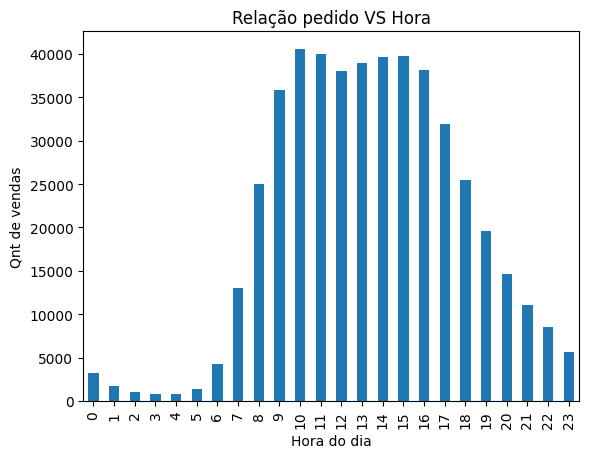

In [80]:
pedido_por_hora = instacart_orders.groupby('order_hour_of_day')['order_number'].count()

print(pedido_por_hora)

pedido_por_hora.plot(title='Relação pedido VS Hora',
                     x='order_hour_of_day',
                     y='order_number',
                     style='o',
                     xlabel='Hora do dia',
                     ylabel='Qnt de vendas',
                     kind='bar',
                     )

Escreva suas conclusões aqui

Percebemos a maior concentração de vendas entres 9 e 17 horas, ultrapasando o valor de 30.000.

 A.3) Em que dia da semana as pessoas compram produtos alimentícios?

order_dow
0    429362
1    395469
6    312480
2    296613
5    294234
3    266906
4    266333
Name: count, dtype: int64


<Axes: title={'center': 'QNT de vendas de Produtos Alimentícios VS Dias Da Semana'}, xlabel='order_dow'>

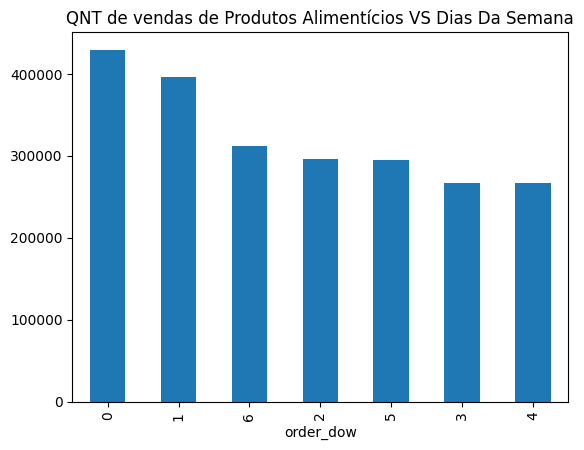

In [83]:
# 1. tenho que listar os produtos alimentícios existentes no DataFrame 'departments.csv'
#print(departments)
id_genero_alimenticios = [1, 3, 9, 12, 14, 15, 16, 19, 20] 

# 2. Conexão dos DataFrames usando o método merge().
connexao_order_id = instacart_orders.merge(order_products, on='order_id')
connexao_product_id = connexao_order_id.merge(products, on='product_id')
connexao_department_id = connexao_product_id.merge(departments, on='department_id')

# 3. Verificar as vendas da semana que são de produtos alimentícios
dia_semana_genero_alimenticios = connexao_department_id.query("department_id in @id_genero_alimenticios")['order_dow'].value_counts()
print(dia_semana_genero_alimenticios)

dia_semana_genero_alimenticios.plot(title='QNT de vendas de Produtos Alimentícios VS Dias Da Semana',
                                    kind='bar',
                                    x='order_dow',
                                    )

Escreva suas conclusões aqui

Podemos notar que todos os dias existem compras de item do genero alimenticio, mas a maior concentração existe nos dias 0 (domingo) e 1 (segunda-feira).

A.4) Quanto tempo as pessoas esperam até fazer seu próximo pedido?

Escreva suas conclusões aqui

As pessoas esperam em média 11 dias para realizarem uma segunda compra.

In [85]:
tempo_entre_pedidos = instacart_orders[instacart_orders['order_number'] > 1]['days_since_prior_order'].mean()
dias = instacart_orders['days_since_prior_order']

print('A média entre os pedidos são de {} dias.'.format(tempo_entre_pedidos))
print()
print('O valor mínimo é {} dias.'.format(dias.min()))
print()
print('O valor máximo é {} dias.'.format(dias.max()))

A média entre os pedidos são de 11.101750979677794 dias.

O valor mínimo é 0.0 dias.

O valor máximo é 30.0 dias.


B) Médio (é necessário concluir tudo para passar)

1. Há alguma diferença nas distribuições de 'order_hour_of_day' nas quartas e sábados? Construa gráficos de barras para ambos os dias no mesmo gráfico e descreva as diferenças que você notou.
2. Construa um gráfico de distribuição para o número de pedidos que os clientes fazem (ou seja, quantos clientes fizeram apenas 1 pedido, quantos fizeram apenas 2, quantos apenas 3, etc.)
3. Quais são os 20 produtos comprados com mais frequência? Exiba os IDs e nomes.


B.1) Diferenças nas quartas e sábados em 'order_hour_of_day'. Crie gráficos de barras para ambos os dias e descreva as diferenças.

In [86]:
quartas = instacart_orders[instacart_orders['order_dow'] == 3]['order_hour_of_day'].value_counts().sort_index()
print(quartas)

order_hour_of_day
0      373
1      215
2      121
3      101
4      108
5      170
6      643
7     1732
8     3125
9     4490
10    5026
11    5004
12    4688
13    4674
14    4774
15    5163
16    4976
17    4175
18    3463
19    2652
20    1917
21    1450
22    1154
23     718
Name: count, dtype: int64


<Axes: title={'center': 'Pedidos durante as Quartas'}, xlabel='Horas do Dia'>

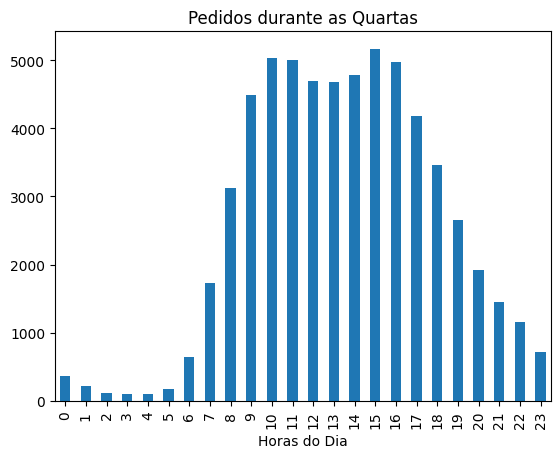

In [87]:
quartas.plot(title='Pedidos durante as Quartas',
             kind='bar',
            # x='order_dow',
             xlabel='Horas do Dia',
             y='order_hour_of_day')
             

In [88]:
sabados = instacart_orders[instacart_orders['order_dow'] == 6]['order_hour_of_day'].value_counts().sort_index()
print()
print((sabados))


order_hour_of_day
0      464
1      254
2      177
3      125
4      118
5      161
6      451
7     1619
8     3246
9     4311
10    4919
11    5116
12    5132
13    5323
14    5375
15    5188
16    5029
17    4295
18    3338
19    2610
20    1847
21    1473
22    1185
23     893
Name: count, dtype: int64


<Axes: title={'center': 'Pedidos durante os Sábados'}, xlabel='Horas do Dia'>

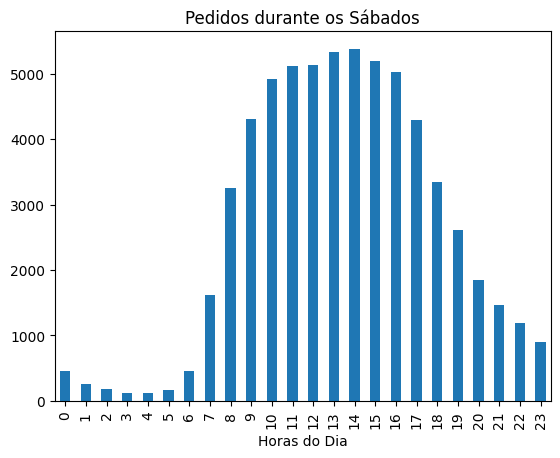

In [89]:
sabados.plot(title='Pedidos durante os Sábados',
             kind='bar',
             x='order_dow',
             xlabel='Horas do Dia',
             y='order_hour_of_day')

Escreva suas conclusões aqui

As vendas nos dois dias se comportam de forma parecedas, Com maior de 9 às 17.

In [90]:
pedidos_por_clientes = instacart_orders.groupby('order_number')['user_id'].count()

print(pedidos_por_clientes)

order_number
1      28819
2      28633
3      28686
4      28704
5      25661
       ...  
96       220
97       221
98       191
99       169
100      194
Name: user_id, Length: 100, dtype: int64


<Axes: xlabel='order_number'>

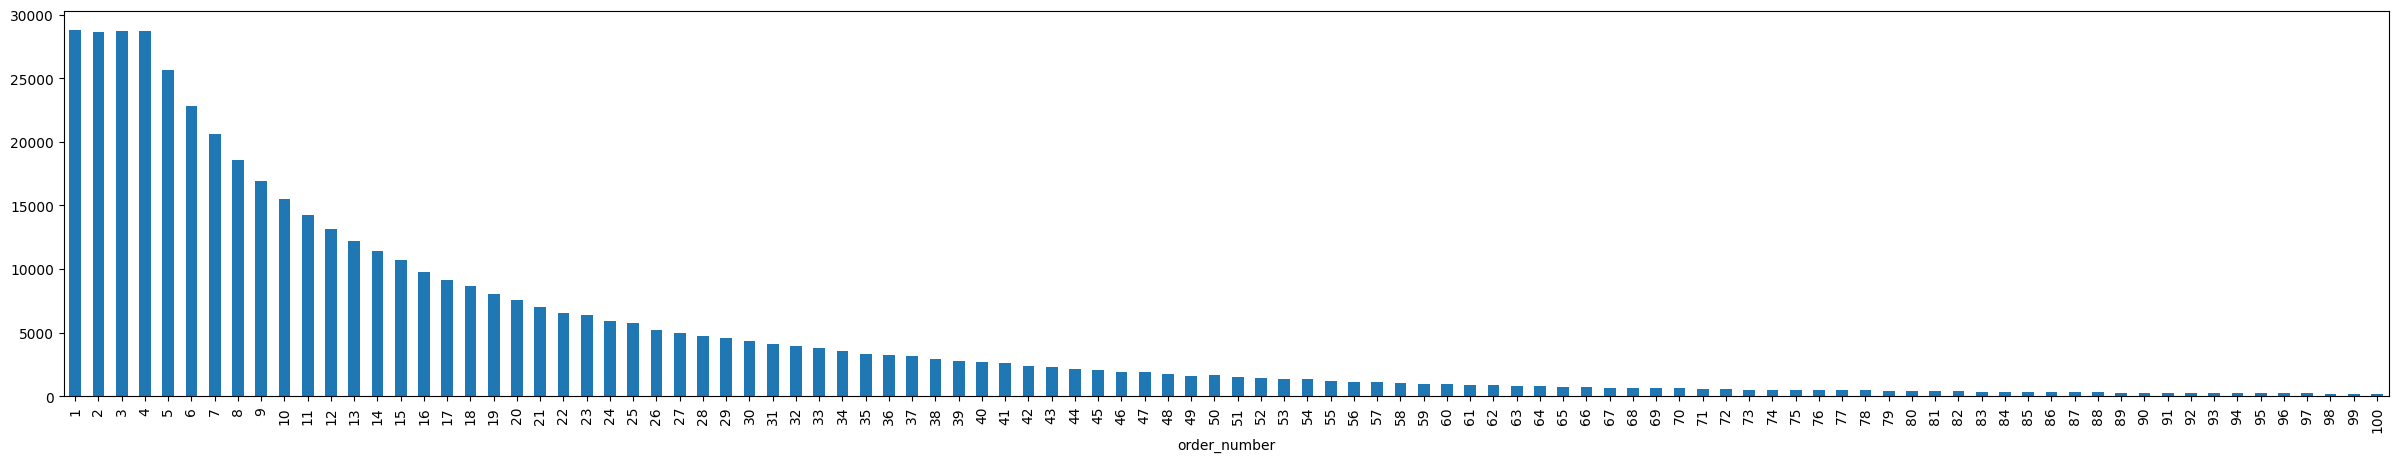

In [91]:
pedidos_por_clientes.plot(kind='bar',figsize=[30,5])

Escreva suas conclusões aqui

Mantem-se uma contancia na relização ate 4 pedidos. Após isso aexiste um declinio em relação a quantidade de pedidos.

B.3) Quais são os 20 produtos mais populares? Exiba os IDs e nomes.

In [92]:
produtos_populares = order_products.merge(products, on='product_id')
print(produtos_populares)

         order_id  product_id  add_to_cart_order  reordered  \
0         2141543       11440                 17          0   
1          567889        1560                  1          1   
2         2261212       26683                  1          1   
3          491251        8670                 35          1   
4         2571142        1940                  5          1   
...           ...         ...                ...        ...   
4545002    577211       15290                 12          1   
4545003   1219554       21914                  9          0   
4545004    692640       47766                  4          1   
4545005    319435         691                  8          1   
4545006   1398151       28733                  9          0   

                                              product_name  aisle_id  \
0                           Chicken Breast Tenders Breaded       129   
1                                               Bag Of Ice        37   
2        Cafe Latte Pure Li

In [93]:
list_20_products = produtos_populares.groupby(['product_id', 'product_name'])['order_id'].size().reset_index().sort_values(by='order_id', ascending=False).head(20)
print(list_20_products)  #.sort_values(ascending=False).head(20))

#print(produtos_populares.groupby('product_name')[list_20_products].)

       product_id              product_name  order_id
22808       24852                    Banana     66050
12025       13176    Bag of Organic Bananas     53297
19370       21137      Organic Strawberries     37039
20077       21903      Organic Baby Spinach     33971
43271       47209      Organic Hass Avocado     29773
43788       47766           Organic Avocado     24689
43663       47626               Large Lemon     21495
15364       16797              Strawberries     20018
24047       26209                     Limes     19690
25556       27845        Organic Whole Milk     19600
25666       27966       Organic Raspberries     19197
21025       22935      Organic Yellow Onion     15898
22908       24964            Organic Garlic     15292
41244       45007          Organic Zucchini     14584
35996       39275       Organic Blueberries     13879
45561       49683            Cucumber Kirby     13675
25889       28204        Organic Fuji Apple     12544
5375         5876           

<Axes: xlabel='product_name'>

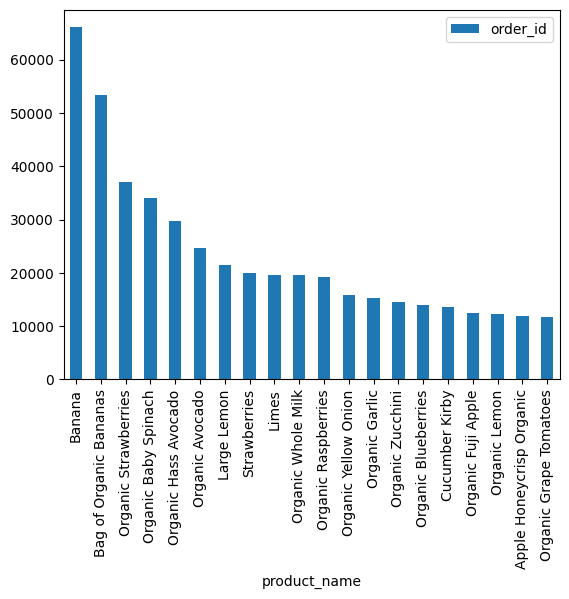

In [94]:
list_20_products.plot(kind='bar', x='product_name', y='order_id')

Escreva suas conclusões aqui

A lista com os 20 produtos mais comprados são do genero de hortifruti.

C) Difícil (é necessário concluir pelo menos duas perguntas para passar)

1. Quantos itens as pessoas normalmente compram em um pedido? Como fica a distribuição?
2. Quais são os 20 principais itens incluídos mais frequentemente em pedidos repetidos? Exiba os IDs e nomes.
3. Para cada produto, qual parcela de seus pedidos são repetidos? Crie uma tabela com colunas de ID e nome do produto e a proporção de pedidos repetidos.
4. Para cada cliente, qual proporção de todos os seus pedidos são repetidos?
5. Quais são os 20 principais itens que as pessoas colocam nos carrinhos antes de todos os outros? Exiba o ID do produto, nome e o número de vezes que ele foi o primeiro a ser adicionado a um carrinho.


C.1) Quantos itens as pessoas normalmente compram em um pedido? Como fica a distribuição?

In [95]:
itens_por_pedido = order_products.groupby('order_id').size()

In [96]:
print(itens_por_pedido.mean())

10.098983215049127


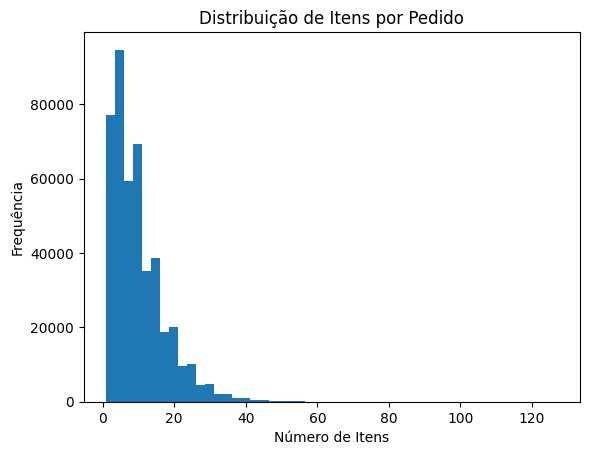

In [97]:
itens_por_pedido.plot(kind='hist',
                      bins=50,
                      title='Distribuição de Itens por Pedido',
                      )
plt.xlabel('Número de Itens')
plt.ylabel('Frequência')
plt.show()

Escreva suas conclusões aqui

Os clientes compram em média 10.09 produtos por pedido.

C.2)  Quais são os 20 principais itens incluídos com mais frequência em pedidos repetidos? Exiba os IDs e nomes.

In [99]:
produtos_repetidos = order_products[order_products['reordered'] == 1]

In [100]:
freq_produtos_repetidos = produtos_repetidos['product_id'].value_counts()

In [101]:
top_20_repetidos = freq_produtos_repetidos.head(20)

In [102]:
top_20_df = top_20_repetidos.reset_index()
top_20_df.columns = ['product_id', 'frequency']
resultado = top_20_df.merge(products[['product_id', 'product_name']], on='product_id')
resultado = resultado[['product_id', 'product_name', 'frequency']]

print(resultado)

    product_id              product_name  frequency
0        24852                    Banana      55763
1        13176    Bag of Organic Bananas      44450
2        21137      Organic Strawberries      28639
3        21903      Organic Baby Spinach      26233
4        47209      Organic Hass Avocado      23629
5        47766           Organic Avocado      18743
6        27845        Organic Whole Milk      16251
7        47626               Large Lemon      15044
8        27966       Organic Raspberries      14748
9        16797              Strawberries      13945
10       26209                     Limes      13327
11       22935      Organic Yellow Onion      11145
12       24964            Organic Garlic      10411
13       45007          Organic Zucchini      10076
14       49683            Cucumber Kirby       9538
15       28204        Organic Fuji Apple       8989
16        8277  Apple Honeycrisp Organic       8836
17       39275       Organic Blueberries       8799
18        58

C.3) Para cada produto, qual parcela de todos os pedidos dele são repetidos?

In [103]:
merg1 = products.merge(order_products, on='product_id')
merg2 = instacart_orders.merge(merg1, on='order_id')

In [104]:
total_pedidos_por_produto = order_products.groupby('product_id').size()

pedidos_repetidos = order_products[order_products['reordered'] == 1]

total_repetidos_por_produto = pedidos_repetidos.groupby('product_id').size()
proporcao_repetidos = total_repetidos_por_produto / total_pedidos_por_produto



In [105]:
proporcao_repetidos_df = proporcao_repetidos.reset_index()
proporcao_repetidos_df.columns = ['product_id', 'reorder_ratio']

resultado = proporcao_repetidos_df.merge(products[['product_id', 'product_name']], on='product_id')

resultado = resultado[['product_id', 'product_name', 'reorder_ratio']]

print(resultado)

       product_id                                       product_name  \
0               1                         Chocolate Sandwich Cookies   
1               2                                   All-Seasons Salt   
2               3               Robust Golden Unsweetened Oolong Tea   
3               4  Smart Ones Classic Favorites Mini Rigatoni Wit...   
4               7                     Pure Coconut Water With Orange   
...           ...                                                ...   
45568       49690                      HIGH PERFORMANCE ENERGY DRINK   
45569       49691                      ORIGINAL PANCAKE & WAFFLE MIX   
45570       49692    ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR   
45571       49693                             SPRING WATER BODY WASH   
45572       49694                            BURRITO- STEAK & CHEESE   

       reorder_ratio  
0           0.564286  
1                NaN  
2           0.738095  
3           0.510204  
4           0.500000

C.4) Para cada cliente, qual proporção de todos os seus pedidos são repetidos?

In [106]:
merg1 = order_products.merge(instacart_orders, on='order_id')
merg2 = products.merge(merg1, on='product_id')

total_pedidos_por_clientes = instacart_orders.groupby('user_id').size()

pedidos_repetidos = order_products[order_products['reordered'] == 1]

total_repetidos_por_produto = pedidos_repetidos.groupby('product_id').size()

proporcao_repetidos = total_pedidos_por_clientes / total_pedidos_por_produto

print(proporcao_repetidos)

1              NaN
2         0.181818
3              NaN
4         0.040816
5              NaN
            ...   
206203         NaN
206206         NaN
206207         NaN
206208         NaN
206209         NaN
Length: 168240, dtype: float64


In [107]:
proporcao_repetidos_df = proporcao_repetidos.reset_index()
proporcao_repetidos_df.columns = ['user_id', 'reorder_ratio']

resultado = proporcao_repetidos_df.merge(instacart_orders[['user_id', 'order_id']], on='user_id')

#resultado = resultado[['user_id', 'product_name', 'reorder_ratio']]

print(resultado)

        user_id  reorder_ratio  order_id
0             2       0.181818   2168274
1             2       0.181818    738281
2             4       0.040816    329954
3             4       0.040816   2030307
4             5            NaN    157374
...         ...            ...       ...
478962   206208            NaN    183408
478963   206208            NaN   2573371
478964   206208            NaN   2017995
478965   206209            NaN    688306
478966   206209            NaN   2977660

[478967 rows x 3 columns]


C.5)Quais são os 20 principais itens que as pessoas colocam nos carrinhos antes de todos os outros?

In [108]:
merg1 = order_products.merge(products, on='product_id')

In [109]:
ordem_sequencial = order_products[order_products['add_to_cart_order'] == 1]

freq_primeiros = ordem_sequencial['product_id'].value_counts()

top_20_primeiros = freq_primeiros.head(20)

In [110]:
top_20_df = top_20_primeiros.reset_index()
top_20_df.columns = ['product_id', 'frequency']

resultado = top_20_df.merge(products[['product_id', 'product_name']], on='product_id')

print(resultado)

    product_id  frequency                 product_name
0        24852      15562                       Banana
1        13176      11026       Bag of Organic Bananas
2        27845       4363           Organic Whole Milk
3        21137       3946         Organic Strawberries
4        47209       3390         Organic Hass Avocado
5        21903       3336         Organic Baby Spinach
6        47766       3044              Organic Avocado
7        19660       2336                 Spring Water
8        16797       2308                 Strawberries
9        27966       2024          Organic Raspberries
10       44632       1914   Sparkling Water Grapefruit
11       49235       1797          Organic Half & Half
12       47626       1737                  Large Lemon
13         196       1733                         Soda
14       38689       1397     Organic Reduced Fat Milk
15       26209       1370                        Limes
16       12341       1340                Hass Avocados
17        

Escreva suas conclusões aqui

Aqui estão listados os 20 primeiros produtos que são incluidos no pedido.

# Conclusão geral do projeto

O estudo sobre o comportamento de compras no Instacart mostrou alguns padrões consistentes na compras. Percebemos que os clientes possuem hábitos de compra, pois os pedidos se concentram na maioria das vezes durante o período do meio dia e finais de semana, e também apresentam compras regulares semanais. O estudo também mostra que os clientes mostram um certa preferencia por certos produtos, são utilizados muitos produtos de uso diário e produtos do genero de hostifruti. Por fim o projeto mostra que os clientes realizam compras frequentes, também mostra que os clientes, em sua grande maioria, podem ser previsíveis, já que compram com grande frequencia e tem preferencia por alguns produtos. Isso abre espaço para melhorias em recomendações, logística e estratégias de retenção de clientes.